In [1]:
import pandas as pd


df = pd.read_csv("marketing_campaign.csv", sep=";")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("marketing_campaign.csv", sep=';')

# Drop ID columns
df = df.drop(columns=["ID", "Dt_Customer"], errors="ignore")

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# Keep numeric columns only for clustering
df_num = df.select_dtypes(include=np.number)

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(df_num)

print("Shape:", X.shape)


Shape: (2240, 25)


Cluster Centers:
 [[ 0.09384507 -0.51653137  0.45379521  0.09851359 -0.00847163 -0.58300776
  -0.4902911  -0.570719   -0.50511763 -0.48922137 -0.40497518  0.11207832
  -0.39578091 -0.60014677 -0.55055873  0.44314105 -0.02273394 -0.14396745
  -0.28014028 -0.24114061 -0.10372645  0.00945893  0.          0.
  -0.15457487]
 [-0.14530506  0.79977156 -0.702634   -0.15253355  0.01311705  0.90270029
   0.75914241  0.88367299  0.78209908  0.7574861   0.62704348 -0.17353652
   0.61280753  0.9292375   0.85245783 -0.68613762  0.0352001   0.22291207
   0.43375531  0.37337016  0.16060489 -0.01464574  0.          0.
   0.23933606]]


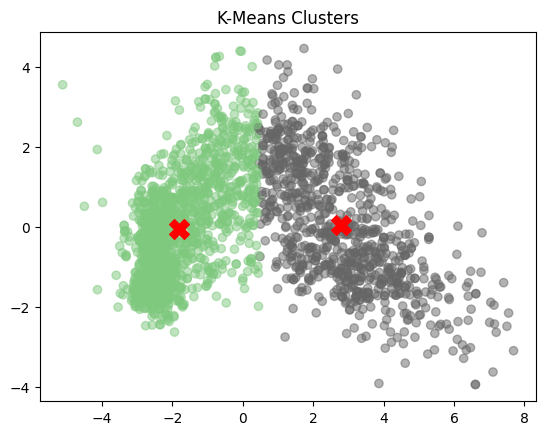

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

print("Cluster Centers:\n", kmeans.cluster_centers_)

# Visualize using PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_kmeans, cmap='Accent', alpha=0.5)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:,0],
            pca.transform(kmeans.cluster_centers_)[:,1],
            c='red', marker='X', s=200)
plt.title("K-Means Clusters")
plt.show()


Means:
 [[ 0.04655398 -0.39409731  0.2880503   0.15959343 -0.00829381 -0.44001033
  -0.3481967  -0.47237128 -0.37838761 -0.36025122 -0.2516321   0.12164078
  -0.18560888 -0.42097435 -0.27880371  0.32434082 -0.01927103 -0.15565392
  -0.28014028 -0.26211122 -0.11651035  0.03455451  0.          0.
  -0.16000023]
 [-0.11006692  0.93175879 -0.6810333  -0.37732453  0.01960893  1.04031029
   0.82323661  1.11682083  0.89461656  0.85173694  0.59493027 -0.28759359
   0.43883249  0.99530379  0.65917174 -0.76683449  0.04556223  0.36801039
   0.66233175  0.6197059   0.27546379 -0.08169674  0.          0.
   0.37828632]]
Weights:
 [0.70276012 0.29723988]


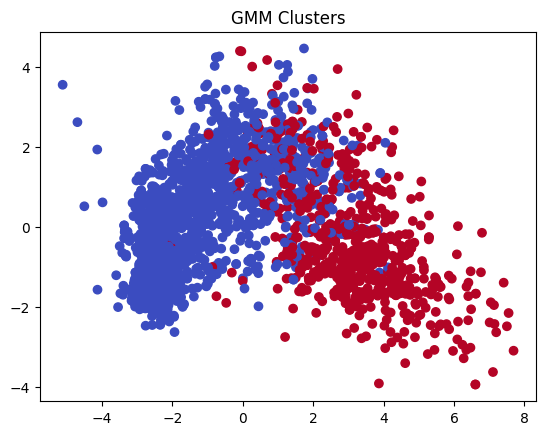

In [23]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
labels_gmm = gmm.fit_predict(X)

print("Means:\n", gmm.means_)
print("Weights:\n", gmm.weights_)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_gmm, cmap='coolwarm')
plt.title("GMM Clusters")
plt.show()
